In [3]:
!pip install -q xgboost shap

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Upload the dataset (skip this if the file is already in /content/)
from google.colab import files
uploaded = files.upload()   # choose car_features_dataset_.csv

df = pd.read_csv("car_features_dataset_.csv")
print("Shape:", df.shape)
df.head()

Saving car_features_dataset_.csv to car_features_dataset_.csv
Shape: (2040, 57)


,Car_ID,Brand,Model,Segment,Year,Price_INR_Lakhs,Engine_CC,Fuel_Type,Transmission,Power_BHP,...,Tyre_Size,Ground_Clearance_mm,Boot_Space_L,Fuel_Tank_L,Wheelbase_mm,Length_mm,Width_mm,Height_mm,Kerb_Weight_kg,Drive_Type
0,1,Maruti Suzuki,Swift,Hatchback,2024,6.99,1197,Petrol,Manual,89,...,175/65 R15,163,268,37,2450,3845,1735,1530,902,FWD
1,2,Maruti Suzuki,Baleno,Hatchback,2024,6.61,1197,Petrol,Manual,89,...,185/65 R15,170,318,37,2520,3990,1745,1500,935,FWD
2,3,Hyundai,i20,Hatchback,2024,7.04,1197,Petrol,Manual,83,...,195/55 R16,172,311,40,2580,4040,1775,1505,971,FWD
3,4,Tata,Tiago,Hatchback,2024,5.60,1199,Petrol,Manual,85,...,175/65 R14,168,242,35,2400,3765,1677,1535,1000,FWD
4,5,Honda,Jazz,Hatchback,2023,8.50,1199,Petrol,Manual,90,...,185/55 R16,130,354,40,2530,3995,1694,1544,1034,FWD



# OBJECTIVE 1
### To conduct a comprehensive Exploratory Data Analysis (EDA) on 2,040 automobile
### records with 57 variables across different measurement scales.

In [5]:
# 1.1 Structure of the dataset
print(df.info())
print("\nMissing values:\n", df.isnull().sum().sum(), "(0 means clean data)")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Data columns (total 57 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Car_ID                      2040 non-null   int64  
 1   Brand                       2040 non-null   object 
 2   Model                       2040 non-null   object 
 3   Segment                     2040 non-null   object 
 4   Year                        2040 non-null   int64  
 5   Price_INR_Lakhs             2040 non-null   float64
 6   Engine_CC                   2040 non-null   int64  
 7   Fuel_Type                   2040 non-null   object 
 8   Transmission                2040 non-null   object 
 9   Power_BHP                   2040 non-null   int64  
 10  Torque_Nm                   2040 non-null   int64  
 11  Mileage_kmpl                2040 non-null   float64
 12  Top_Speed_kmph              2040 non-null   int64  
 13  No_of_Airbags               2040 

In [6]:
# 1.2 Descriptive statistics for continuous variables
desc = df.describe().T
desc["skewness"] = df.select_dtypes(include=np.number).skew()
desc["kurtosis"] = df.select_dtypes(include=np.number).kurt()
desc[["mean", "std", "min", "max", "skewness", "kurtosis"]].round(2)

,mean,std,min,max,skewness,kurtosis
Car_ID,1020.50,589.04,1.00,2040.00,0.00,-1.20
Year,2021.57,1.72,2019.00,2024.00,-0.05,-1.28
Price_INR_Lakhs,50.37,55.59,1.32,249.96,1.87,2.97
Engine_CC,1771.55,743.11,800.00,3900.00,0.79,-0.09
Power_BHP,191.58,87.47,54.00,450.00,0.36,-0.80
Torque_Nm,275.40,131.91,72.00,779.00,0.54,-0.34
Mileage_kmpl,16.75,3.84,8.00,27.97,-0.24,-0.75
Top_Speed_kmph,193.28,33.81,140.00,280.00,0.66,-0.42
No_of_Airbags,6.31,2.75,2.00,12.00,0.16,-0.60
NCAP_Rating,3.23,2.04,0.00,5.00,-0.77,-1.10


In [7]:
# 1.3 Frequency distribution of key categorical (nominal) variables
for col in ["Segment", "Fuel_Type", "Transmission", "Drive_Type"]:
    print(f"\n{col}:\n", df[col].value_counts())


Segment:
 Segment
SUV          612
Hatchback    560
Sedan        458
Luxury       410
Name: count, dtype: int64

Fuel_Type:
 Fuel_Type
Petrol           1015
Diesel            562
Petrol Hybrid     282
Electric           98
CNG                83
Name: count, dtype: int64

Transmission:
 Transmission
Manual       797
Automatic    529
AMT          331
CVT          225
DCT          158
Name: count, dtype: int64

Drive_Type:
 Drive_Type
FWD    1005
RWD     373
4WD     358
AWD     304
Name: count, dtype: int64


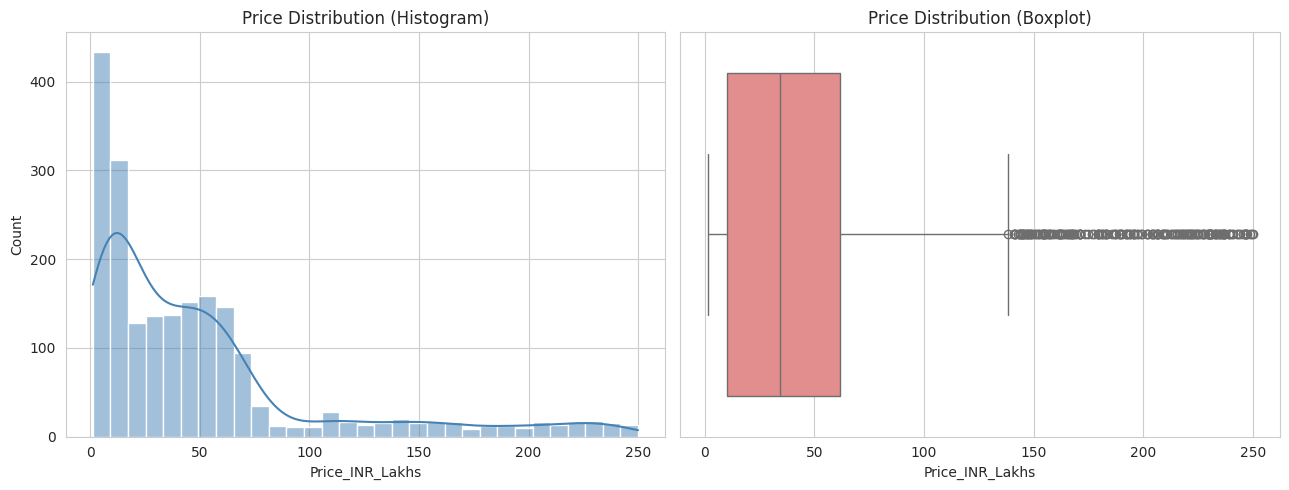

Interpretation: Price is right-skewed (skew = 1.87 ) — most cars are affordable, with a long tail of luxury cars.


In [9]:
# 1.4 Visualization — Price distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["Price_INR_Lakhs"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Price Distribution (Histogram)")
sns.boxplot(x=df["Price_INR_Lakhs"], ax=axes[1], color="lightcoral")
axes[1].set_title("Price Distribution (Boxplot)")
plt.tight_layout(); plt.show()

print("Interpretation: Price is right-skewed (skew =",
      round(df["Price_INR_Lakhs"].skew(), 2),
      ") — most cars are affordable, with a long tail of luxury cars.")

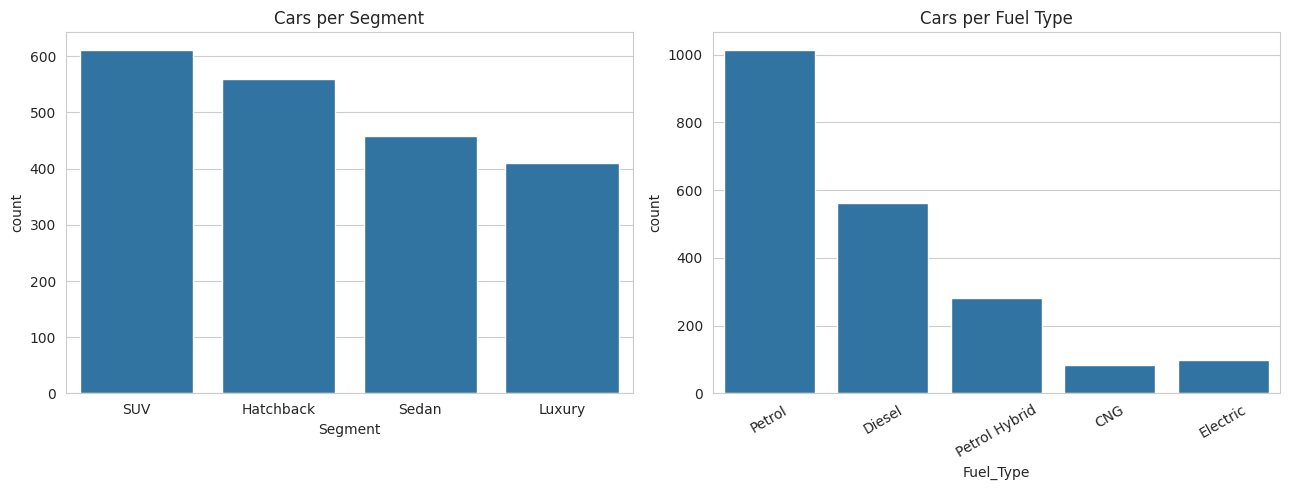

In [10]:
# 1.5 Visualization - counts by Segment and Fuel Type
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=df, x="Segment", order=df["Segment"].value_counts().index, ax=axes[0])
axes[0].set_title("Cars per Segment")
sns.countplot(data=df, x="Fuel_Type", ax=axes[1])
axes[1].set_title("Cars per Fuel Type")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()


# OBJECTIVE 2
### To examine the relationship between car specifications and price using
### correlation analysis (and a quick look at the airbags–price relationship).

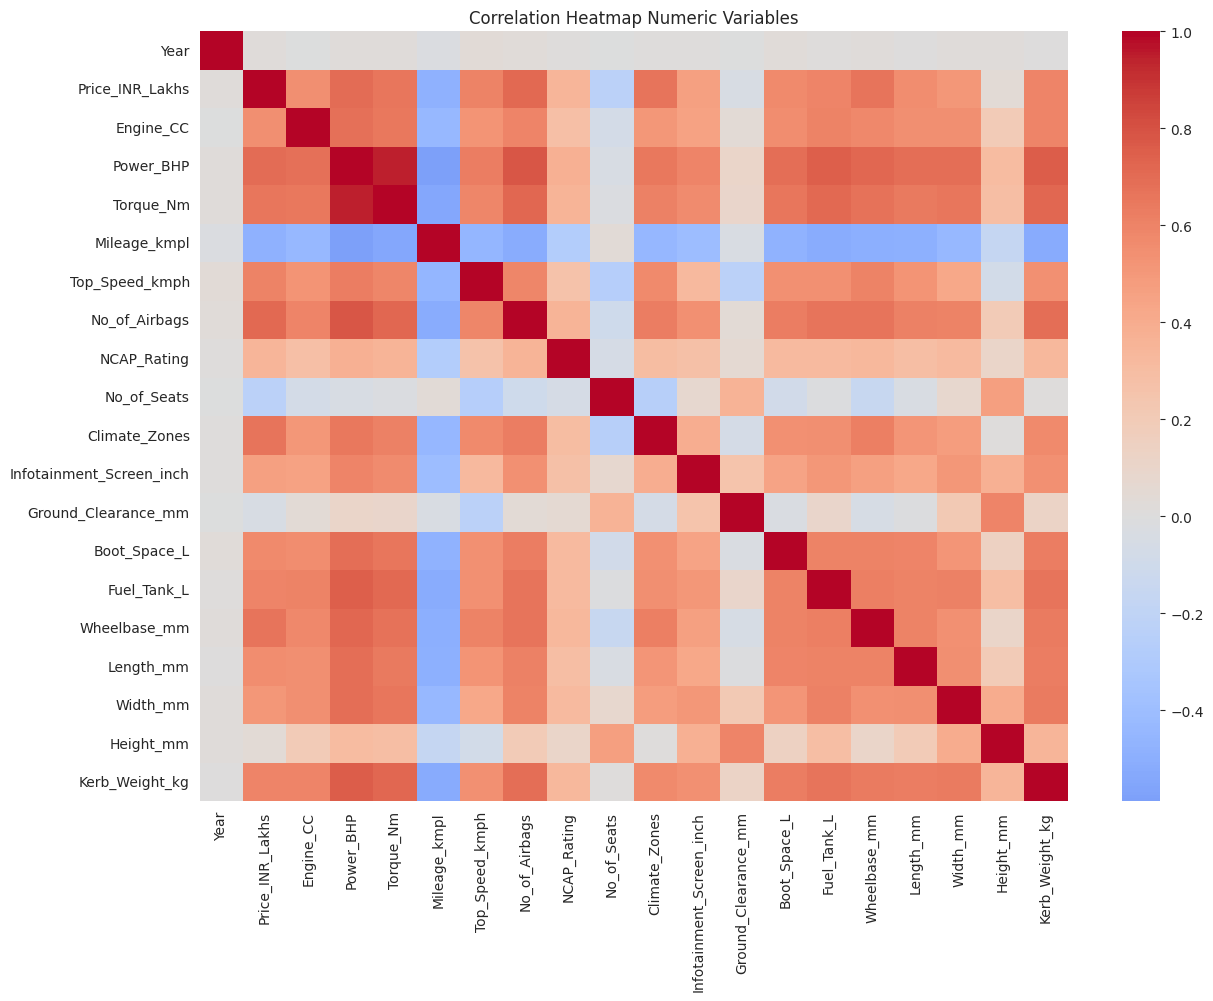

Top 5 features correlated with Price:
 No_of_Airbags    0.713
Power_BHP        0.702
Climate_Zones    0.668
Wheelbase_mm     0.666
Torque_Nm        0.653
Name: Price_INR_Lakhs, dtype: float64


In [11]:
# 2.0 Correlation matrix (Pearson) for the EDA / multicollinearity check
numeric_df = df.select_dtypes(include=np.number).drop(columns=["Car_ID"])
corr = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap Numeric Variables")
plt.show()

top_corr = corr["Price_INR_Lakhs"].drop("Price_INR_Lakhs").sort_values(ascending=False)
print("Top 5 features correlated with Price:\n", top_corr.head(5).round(3))

### Airbags and Price - Pearson correlation + Simple Linear Regression
**H0:** No significant linear relationship between number of airbags and price.
**H1:** A significant positive linear relationship exists.

Pearson r = 0.713, p = 8.81e-317
Decision: Reject H0 -> significant positive relationship

Regression equation: Price = -40.56 + 14.40 * No_of_Airbags
R-squared = 0.509


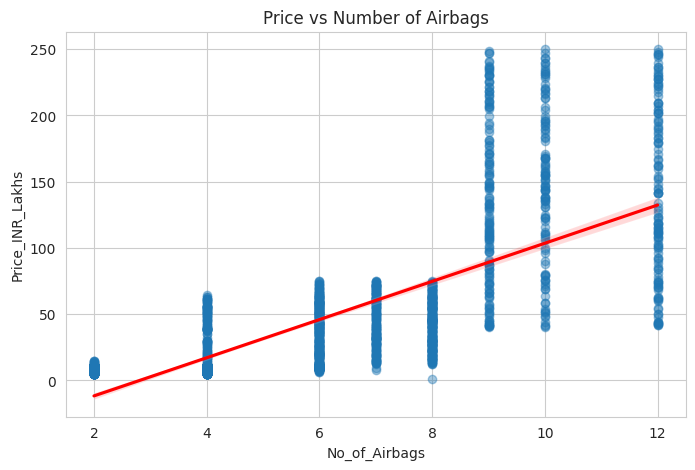

In [12]:
from sklearn.linear_model import LinearRegression

r, p_value = stats.pearsonr(df["No_of_Airbags"], df["Price_INR_Lakhs"])
print(f"Pearson r = {r:.3f}, p = {p_value:.2e}")
print("Decision:", "Reject H0 -> significant positive relationship" if p_value < 0.05
      else "Fail to reject H0")

slr = LinearRegression().fit(df[["No_of_Airbags"]], df["Price_INR_Lakhs"])
print(f"\nRegression equation: Price = {slr.intercept_:.2f} + {slr.coef_[0]:.2f} * No_of_Airbags")
print(f"R-squared = {slr.score(df[['No_of_Airbags']], df['Price_INR_Lakhs']):.3f}")

plt.figure()
sns.regplot(data=df, x="No_of_Airbags", y="Price_INR_Lakhs",
            scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
plt.title("Price vs Number of Airbags")
plt.show()


# OBJECTIVE 3
### To evaluate price differences across segments and fuel types using ANOVA,
### Kruskal-Wallis, and post-hoc analysis.

### Segment and Price - One-Way ANOVA + Tukey's HSD Post-Hoc Test
**H0:** No significant difference in mean price across the 4 segments (Hatchback, Sedan, SUV, Luxury).
**H1:** At least one segment has a significantly different mean price.

ANOVA: F = 1481.96, p = 0.000000
Decision: Reject H0 -> segments differ significantly in price

Tukey HSD post-hoc test:
     Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1  group2  meandiff p-adj    lower    upper   reject
-----------------------------------------------------------
Hatchback Luxury  130.2409    0.0    125.03 135.4518   True
Hatchback    SUV   32.6245    0.0   27.9362  37.3127   True
Hatchback  Sedan   28.0965    0.0   23.0457  33.1473   True
   Luxury    SUV  -97.6164    0.0 -102.7329    -92.5   True
   Luxury  Sedan -102.1444    0.0 -107.5951 -96.6937   True
      SUV  Sedan    -4.528 0.0873   -9.4813   0.4254  False
-----------------------------------------------------------


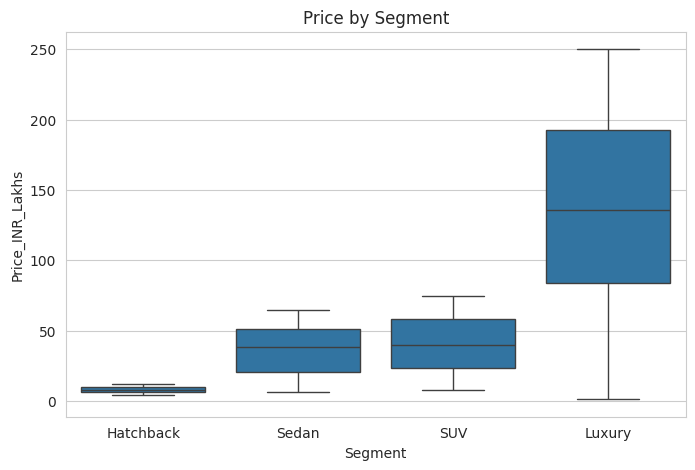

In [13]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# One-Way ANOVA
groups = [g["Price_INR_Lakhs"].values for _, g in df.groupby("Segment")]
f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA: F = {f_stat:.2f}, p = {p_value:.6f}")
print("Decision:", "Reject H0 -> segments differ significantly in price" if p_value < 0.05
      else "Fail to reject H0")

# Tukey HSD post-hoc — tells us WHICH segment pairs differ
tukey = pairwise_tukeyhsd(df["Price_INR_Lakhs"], df["Segment"], alpha=0.05)
print("\nTukey HSD post-hoc test:\n", tukey)

plt.figure()
sns.boxplot(data=df, x="Segment", y="Price_INR_Lakhs")
plt.title("Price by Segment")
plt.show()

### Fuel Type and Mileage - Kruskal-Wallis Test
**H0:** No significant difference in mean mileage across fuel types (Petrol,
Diesel, Petrol Hybrid, CNG, Electric).
**H1:** At least one fuel type shows significantly different mileage.
**Test:** Kruskal-Wallis H Test (non-parametric, since mileage is not normally
distributed across all 5 fuel-type groups).

Kruskal-Wallis: H = 111.59, p = 3.33e-23
Decision: Reject H0 -> mileage differs significantly by fuel type


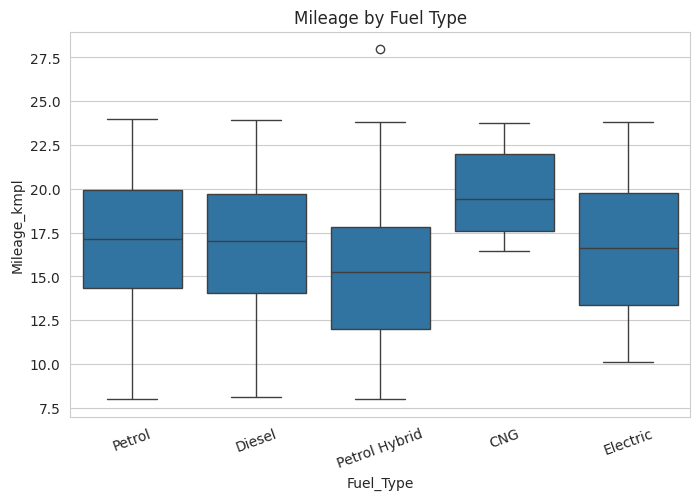

In [14]:
groups_fuel = [g["Mileage_kmpl"].values for _, g in df.groupby("Fuel_Type")]
h_stat, p_value = stats.kruskal(*groups_fuel)
print(f"Kruskal-Wallis: H = {h_stat:.2f}, p = {p_value:.2e}")
print("Decision:", "Reject H0 -> mileage differs significantly by fuel type" if p_value < 0.05
      else "Fail to reject H0")

plt.figure()
sns.boxplot(data=df, x="Fuel_Type", y="Mileage_kmpl")
plt.title("Mileage by Fuel Type")
plt.xticks(rotation=20)
plt.show()


# OBJECTIVE 4
### To analyze the association between categorical safety features and
### automobile segment using the Chi-Square Test of Independence.

### Safety Features and Segment - Chi-Square Test of Independence
**H0:** Distribution of safety features (ESP, Blind Spot Monitor, Lane Departure
Warning, Auto Emergency Braking) is independent of automobile segment.
**H1:** Significant association exists.

In [15]:
safety_features = ["ESP", "Blind_Spot_Monitor", "Lane_Departure_Warning", "Auto_Emergency_Braking"]

for feature in safety_features:
    table = pd.crosstab(df[feature], df["Segment"])
    chi2, p_value, dof, expected = stats.chi2_contingency(table)
    decision = "Significant association" if p_value < 0.05 else "No significant association"
    print(f"{feature:28s}: chi2 = {chi2:6.2f}, dof = {dof}, p = {p_value:.4f}  ->  {decision}")

ESP                         : chi2 =   8.18, dof = 3, p = 0.0424  ->  Significant association
Blind_Spot_Monitor          : chi2 =   6.69, dof = 3, p = 0.0823  ->  No significant association
Auto_Emergency_Braking      : chi2 =  12.82, dof = 3, p = 0.0050  ->  Significant association



# OBJECTIVE 5
### To build and compare multiple regression models, perform market
### segmentation (K-Means + Hierarchical Clustering + PCA), and interpret the
### models using feature importance and SHAP values.

## 5. Regression Models - Price Prediction
Linear Regression, Ridge Regression, Lasso Regression, Random Forest
Regressor, and XGBoost Regressor, compared on R², RMSE, and MAE.

            Model  R2_Score   RMSE    MAE
    Random Forest     0.892 19.247 11.244
          XGBoost     0.887 19.698 11.305
Linear Regression     0.735 30.117 20.598
 Ridge Regression     0.735 30.118 20.596
 Lasso Regression     0.734 30.161 20.555


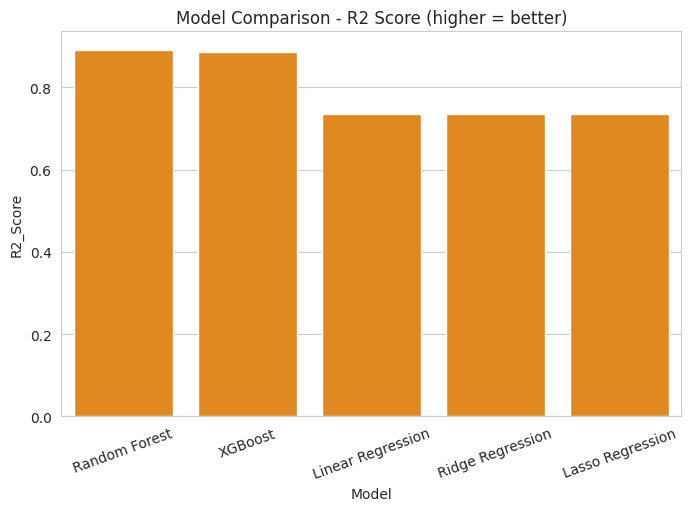


Interpretation: the model with the highest R2 and lowest RMSE/MAE is the best price predictor. Tree-based models (Random Forest, XGBoost) usually outperform linear models because price depends on features non-linearly.


In [16]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# Encode all text columns to numbers so the models can use every feature
model_df = df.copy()
for col in model_df.select_dtypes(include=["object"]).columns:
    model_df[col] = LabelEncoder().fit_transform(model_df[col].astype(str))

X = model_df.drop(columns=["Price_INR_Lakhs", "Car_ID"])
y = model_df["Price_INR_Lakhs"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=1.0),
    "Lasso Regression":  Lasso(alpha=0.1),
    "Random Forest":     RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost":           XGBRegressor(n_estimators=200, learning_rate=0.05,
                                       max_depth=5, random_state=42),
}

results = []
for name, model in models.items():
    if name in ["Random Forest", "XGBoost"]:        # tree models don't need scaling
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
    else:
        model.fit(X_train_s, y_train)
        pred = model.predict(X_test_s)
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    results.append([name, r2, rmse, mae])

results_df = pd.DataFrame(results, columns=["Model", "R2_Score", "RMSE", "MAE"]) \
               .sort_values("R2_Score", ascending=False)
print(results_df.round(3).to_string(index=False))

plt.figure()
sns.barplot(data=results_df, x="Model", y="R2_Score", color="darkorange")
plt.title("Model Comparison - R2 Score (higher = better)")
plt.xticks(rotation=20)
plt.show()

print("\nInterpretation: the model with the highest R2 and lowest RMSE/MAE is the "
      "best price predictor. Tree-based models (Random Forest, XGBoost) usually "
      "outperform linear models because price depends on features non-linearly.")

## 5a. Market Segmentation - K-Means & Hierarchical Clustering
Optimal number of clusters is determined using the Elbow Method and
Silhouette Score.

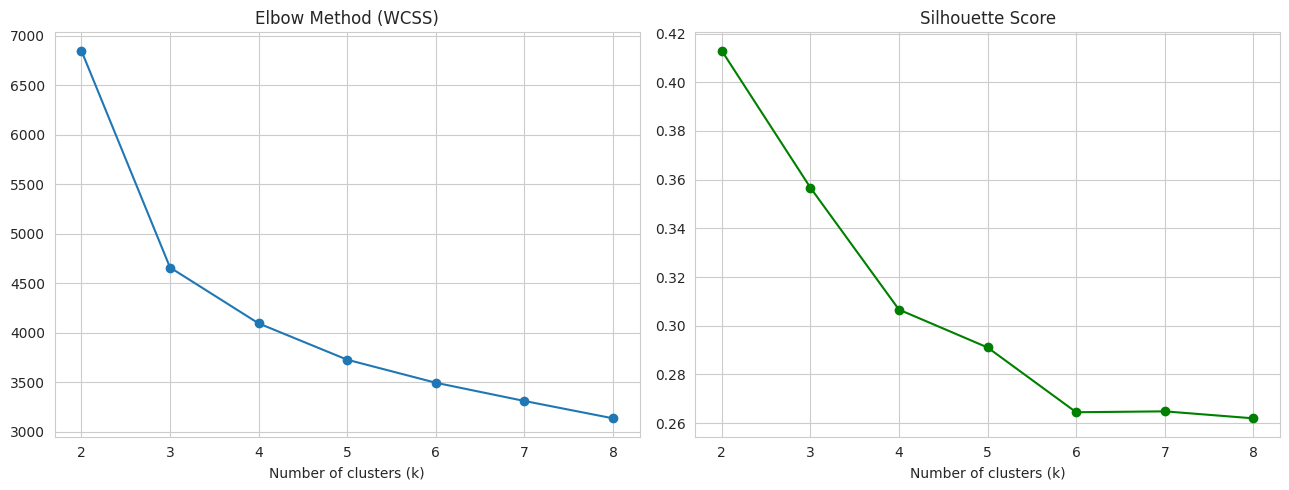

Silhouette scores by k: {2: np.float64(0.413), 3: np.float64(0.357), 4: np.float64(0.307), 5: np.float64(0.291), 6: np.float64(0.264), 7: np.float64(0.265), 8: np.float64(0.262)}
Interpretation: the k with the highest silhouette score (and the 'elbow' point in WCSS) is the statistically optimal number of clusters.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

cluster_features = ["Price_INR_Lakhs", "Engine_CC", "Power_BHP",
                     "Mileage_kmpl", "Boot_Space_L", "No_of_Airbags"]
X_cluster = StandardScaler().fit_transform(df[cluster_features])

# 4.1 Elbow Method (WCSS) + Silhouette Score for k = 2 to 8
wcss, sil_scores = [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cluster)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(range(2, 9), wcss, marker="o")
axes[0].set_title("Elbow Method (WCSS)")
axes[0].set_xlabel("Number of clusters (k)")
axes[1].plot(range(2, 9), sil_scores, marker="o", color="green")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
plt.tight_layout(); plt.show()

print("Silhouette scores by k:", dict(zip(range(2, 9), [round(s, 3) for s in sil_scores])))
print("Interpretation: the k with the highest silhouette score (and the 'elbow' "
      "point in WCSS) is the statistically optimal number of clusters.")

In [ ]:
# 4.2 K-Means clustering with the chosen k (k=4 lets us compare directly with
# the 4 manufacturer-defined segments - change this if your elbow/silhouette
# plot above points to a different k)
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df["KMeans_Cluster"] = kmeans.fit_predict(X_cluster)

print("Cars per cluster:\n", df["KMeans_Cluster"].value_counts().sort_index())
print("\nCluster profile (average specs per cluster):")
print(df.groupby("KMeans_Cluster")[cluster_features].mean().round(1))

# Compare data-driven clusters against the manufacturer's own Segment labels
print("\nK-Means cluster vs manufacturer-defined Segment:")
print(pd.crosstab(df["KMeans_Cluster"], df["Segment"]))

Cars per cluster:
 KMeans_Cluster
0    389
1    505
2    600
3    546
Name: count, dtype: int64

Cluster profile (average specs per cluster):
                Price_INR_Lakhs  Engine_CC  Power_BHP  Mileage_kmpl  \
KMeans_Cluster                                                        
0                         142.5     2657.1      318.5          13.0   
1                          39.3     1829.7      205.8          13.4   
2                           8.7     1069.6       90.1          19.9   
3                          40.7     1858.3      199.5          19.1   

                Boot_Space_L  No_of_Airbags  
KMeans_Cluster                               
0                      655.4           10.3  
1                      485.4            6.4  
2                      317.3            3.6  
3                      481.5            6.5  

K-Means cluster vs manufacturer-defined Segment:
Segment         Hatchback  Luxury  SUV  Sedan
KMeans_Cluster                               
0            

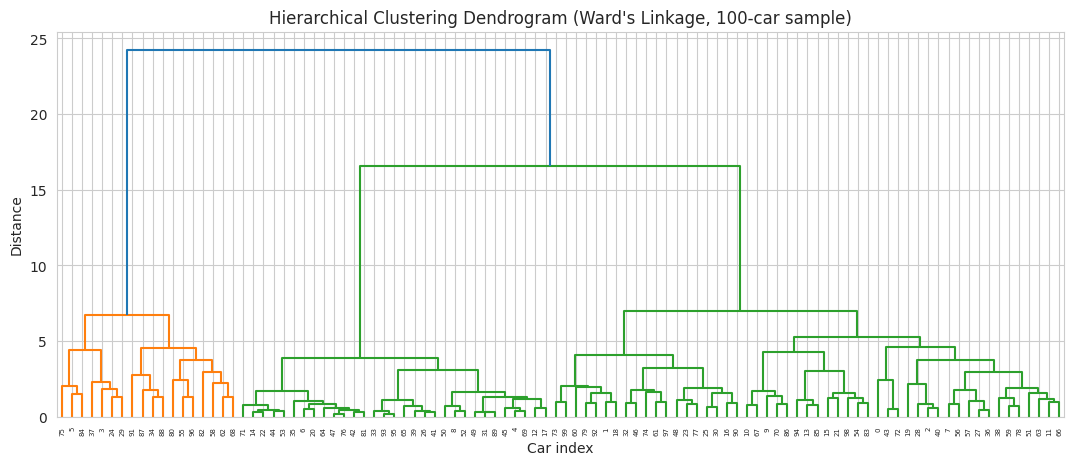

Hierarchical cluster sizes: {1: 397, 2: 571, 3: 438, 4: 634}

Agreement check (K-Means vs Hierarchical clusters):
Hierarchical_Cluster    1    2    3    4
KMeans_Cluster                          
0                     386    0    2    1
1                       9    0  362  134
2                       0  571    0   29
3                       2    0   74  470


In [ ]:
# 4.3 Hierarchical (Agglomerative) Clustering — Ward's linkage, with dendrogram
# A 100-car random sample is used only for the dendrogram so it stays readable
sample = pd.DataFrame(X_cluster).sample(100, random_state=42).values
linked = linkage(sample, method="ward")

plt.figure(figsize=(13, 5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram (Ward's Linkage, 100-car sample)")
plt.xlabel("Car index")
plt.ylabel("Distance")
plt.show()

# Apply the same k to the full dataset for comparison with K-Means
full_linkage = linkage(X_cluster, method="ward")
df["Hierarchical_Cluster"] = fcluster(full_linkage, t=K, criterion="maxclust")
print("Hierarchical cluster sizes:", df["Hierarchical_Cluster"].value_counts().sort_index().to_dict())
print("\nAgreement check (K-Means vs Hierarchical clusters):")
print(pd.crosstab(df["KMeans_Cluster"], df["Hierarchical_Cluster"]))

## 5b. Principal Component Analysis (PCA)
Used for dimensionality reduction and visualization of the high-dimensional
specification space.

Explained variance ratio per component: [0.669 0.098 0.08 ]
Total variance explained by 3 components: 84.7 %


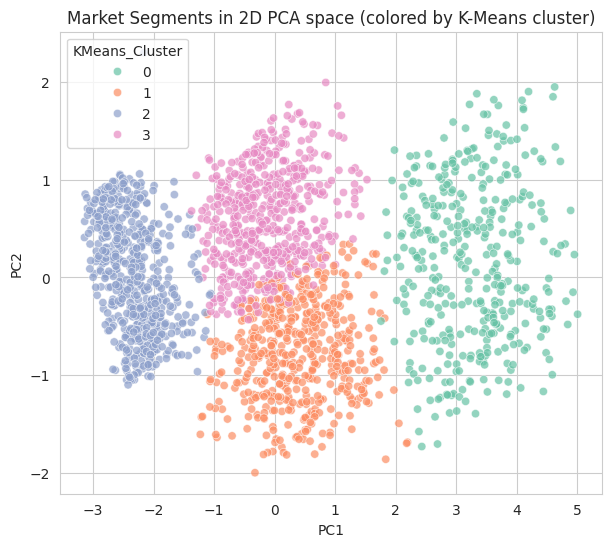

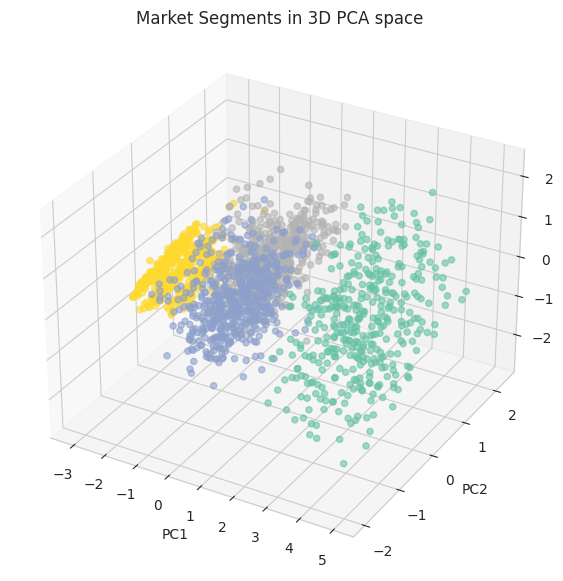

Interpretation: PCA compresses the 6 specification variables into a few components that capture most of the variance, letting us *see* the clusters that would otherwise need 6+ dimensions.


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3, random_state=42)
components = pca.fit_transform(X_cluster)
df["PC1"], df["PC2"], df["PC3"] = components[:, 0], components[:, 1], components[:, 2]

print("Explained variance ratio per component:", pca.explained_variance_ratio_.round(3))
print("Total variance explained by 3 components:",
      round(pca.explained_variance_ratio_.sum() * 100, 1), "%")

# 2D scatter colored by K-Means cluster
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="KMeans_Cluster", palette="Set2", alpha=0.7)
plt.title("Market Segments in 2D PCA space (colored by K-Means cluster)")
plt.show()

# 3D scatter
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(df["PC1"], df["PC2"], df["PC3"], c=df["KMeans_Cluster"], cmap="Set2", alpha=0.6)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
ax.set_title("Market Segments in 3D PCA space")
plt.show()

print("Interpretation: PCA compresses the 6 specification variables into a few "
      "components that capture most of the variance, letting us *see* the "
      "clusters that would otherwise need 6+ dimensions.")

## 5c. Model Interpretation - Feature Importance & SHAP

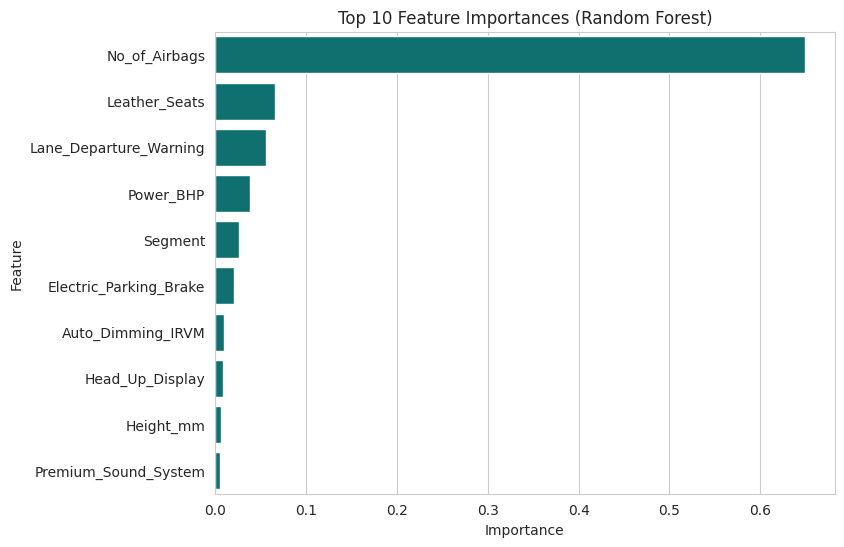

               Feature  Importance
         No_of_Airbags       0.649
         Leather_Seats       0.066
Lane_Departure_Warning       0.056
             Power_BHP       0.039
               Segment       0.026
Electric_Parking_Brake       0.021
     Auto_Dimming_IRVM       0.010
       Head_Up_Display       0.009
             Height_mm       0.007
  Premium_Sound_System       0.006


In [ ]:
# 6.1 Random Forest feature importance
rf_model = models["Random Forest"]
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, y="Feature", x="Importance", color="teal")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()
print(importance_df.round(3).to_string(index=False))

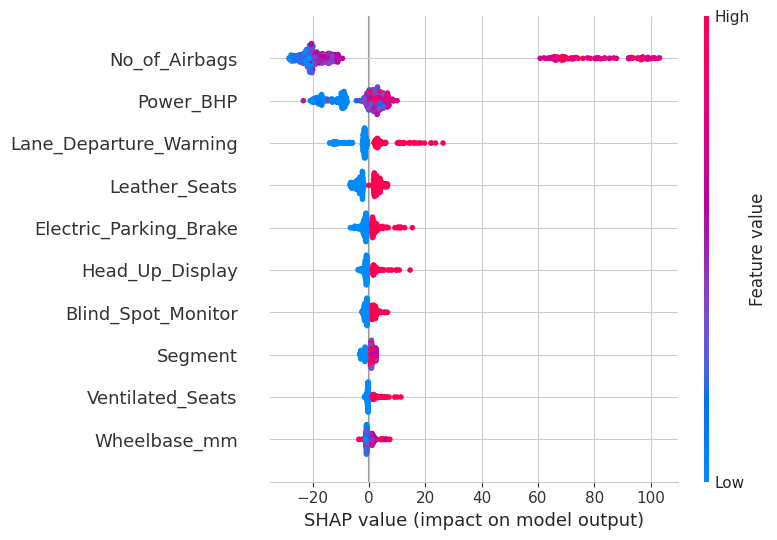

Interpretation: features at the top have the largest impact on price predictions. Red points = high feature value pushing price UP; blue points = low feature value pushing price DOWN.


In [ ]:
import shap

# 6.2 SHAP values for the XGBoost model — explains HOW each feature pushes
# a prediction up or down, not just its overall importance
xgb_model = models["XGBoost"]
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, max_display=10)

print("Interpretation: features at the top have the largest impact on price "
      "predictions. Red points = high feature value pushing price UP; "
      "blue points = low feature value pushing price DOWN.")

In [2]:
print("FINAL SUMMARY - fill in your own numbers from the cells above\n")

best_model_row = results_df.iloc[0]
print(f"1. Best price-prediction model : {best_model_row['Model']} "
      f"(R2 = {best_model_row['R2_Score']:.3f}, RMSE = {best_model_row['RMSE']:.2f} lakhs)")

print(f"2. Strongest price driver (correlation) : {top_corr.index[0]} "
      f"(r = {top_corr.iloc[0]:.3f})")

print(f"3. Optimal number of market segments (silhouette) : "
      f"k = {list(range(2,9))[int(np.argmax(sil_scores))]}")

print("4. Hypotheses tested      : Segment-Price (ANOVA), Airbags-Price "
      "(Pearson/SLR), Safety-Segment (Chi-Square), FuelType-Mileage (Kruskal-Wallis)")

print("\nRecommendation: dealers and OEMs can use the top SHAP/feature-importance "
      "drivers to price new models competitively, while the K-Means clusters can "
      "guide targeted marketing independent of traditional segment labels.")

FINAL SUMMARY - fill in your own numbers from the cells above



NameError: name 'results_df' is not defined